## DATA200 Final Project



Imports

In [193]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, mean_absolute_error

In [194]:
batting_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/Batting.csv"
players_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/People.csv"
fielding_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/Fielding.csv"
people_info = pd.read_csv(players_url)
batting_info = pd.read_csv(batting_url)
fielding_info = pd.read_csv(fielding_url)[['playerID', 'POS']]

In [195]:
hitting_stats = pd.merge(batting_info, people_info, on='playerID', how='inner')
players_stats = pd.merge(fielding_info, hitting_stats, on='playerID', how='inner')
players_stats = players_stats[players_stats['POS'] != 'P']
print(players_stats.head())

     playerID POS  yearID  stint teamID lgID    G   AB    R    H  ...  \
81  aaronha01  OF    1954      1    ML1   NL  122  468   58  131  ...   
82  aaronha01  OF    1955      1    ML1   NL  153  602  105  189  ...   
83  aaronha01  OF    1956      1    ML1   NL  153  609  106  200  ...   
84  aaronha01  OF    1957      1    ML1   NL  151  615  118  198  ...   
85  aaronha01  OF    1958      1    ML1   NL  153  601  109  196  ...   

    nameLast    nameGiven  weight  height  bats  throws       debut  \
81     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
82     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
83     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
84     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
85     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   

      bbrefID   finalGame   retroID  
81  aaronha01  1976-10-03  aaroh101  
82  aaronha01  1976-10-03  aaroh101  
83  aaronha01  1976-

In [196]:
players_stats['debut_year'] = pd.to_datetime(players_stats['debut']).dt.year
players_stats = players_stats[players_stats['debut_year'] >= 2004]
players_stats['debut_year'] = players_stats['debut_year'].astype(int)

players_stats['years_in'] = players_stats['yearID'] - players_stats['debut_year']

In [197]:
players_stats = players_stats[players_stats['stint'] == 1]


In [198]:
columns_to_drop = ['POS', 'stint', 'teamID', 'lgID', 'birthMonth', 'birthDay',
                   'birthCity', 'birthCountry', 'birthState', 'deathYear', 'deathMonth',
                   'deathDay', 'deathCity', 'deathCountry', 'deathState', 'throws', 'debut', 'finalGame', 'bbrefID', 'retroID']
players_stats = players_stats.drop(columns=columns_to_drop)
print(players_stats.head())

       playerID  yearID    G   AB   R   H  2B  3B  HR   RBI  ...  ID  \
2448  abercre01    2006  111  255  39  54  12   2   5  24.0  ...  23   
2449  abercre01    2007   35   76  16  15   3   0   2   5.0  ...  23   
2450  abercre01    2008   34   55  10  17   5   0   2   5.0  ...  23   
2451  abercre01    2006  111  255  39  54  12   2   5  24.0  ...  23   
2452  abercre01    2007   35   76  16  15   3   0   2   5.0  ...  23   

      birthYear  nameFirst     nameLast          nameGiven  weight  height  \
2448     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2449     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2450     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2451     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2452     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   

      bats  debut_year  years_in  
2448     R        2006         0  
2449     R        2006      

In [199]:
players_stats = players_stats.drop_duplicates()

In [200]:
players_stats['1B'] = players_stats['H'] - (players_stats['2B'] + players_stats['3B'] + players_stats['HR'])

players_stats['uBB'] = players_stats['BB'] - players_stats['IBB']

players_stats['wOBA'] = (0.69*players_stats['uBB']+0.722*players_stats['HBP']+0.888*players_stats['1B']+1.271*players_stats['2B']+1.616*players_stats['3B']+2.101*players_stats['HR'])/(players_stats['AB']+players_stats['BB']-players_stats['IBB']+players_stats['SF']+players_stats['HBP'])

In [201]:
MIN_AB = 100
MIN_G  = 30

players_stats = players_stats[(players_stats['AB'] >= MIN_AB) & (players_stats['G'] >= MIN_G)]

In [202]:
players_stats = players_stats.sort_values(['playerID', 'yearID'])

players_stats['woba_prev_year'] = players_stats.groupby('playerID')['wOBA'].shift(1)

players_stats['woba_yoy_pct'] = ((players_stats['wOBA'] - players_stats['woba_prev_year']) / players_stats['woba_prev_year'])*100

BREAKOUT_THRESHOLD = players_stats[players_stats['yearID'] < 2024]['woba_yoy_pct'].quantile(0.75)

players_stats['breakout'] = (players_stats['woba_yoy_pct'] >= BREAKOUT_THRESHOLD).astype(int)

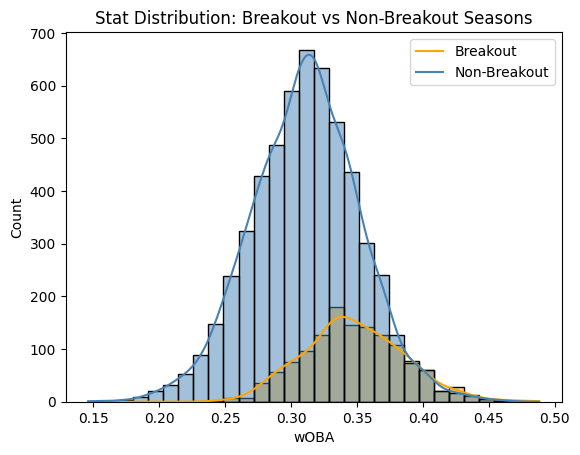

In [203]:
sns.histplot(data=players_stats, x='wOBA', hue='breakout',
             kde=True, bins=30, palette={0: 'steelblue', 1: 'orange'})

plt.title('Stat Distribution: Breakout vs Non-Breakout Seasons')
plt.xlabel('wOBA')
plt.ylabel('Count')
plt.legend(labels=['Breakout', 'Non-Breakout'])
plt.show()

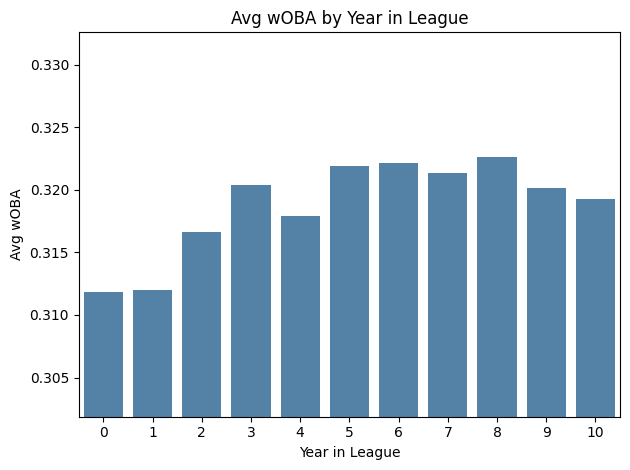

In [204]:
avg_players_stats = players_stats[players_stats['years_in'] <= 10].groupby('years_in')['wOBA'].mean().reset_index()

sns.barplot(data=avg_players_stats, x='years_in', y='wOBA', color='steelblue')

plt.title('Avg wOBA by Year in League')
plt.xlabel('Year in League')
plt.ylabel('Avg wOBA')

plt.ylim(avg_players_stats['wOBA'].min() - 0.01, avg_players_stats['wOBA'].max() + 0.01)

plt.tight_layout()
plt.show()

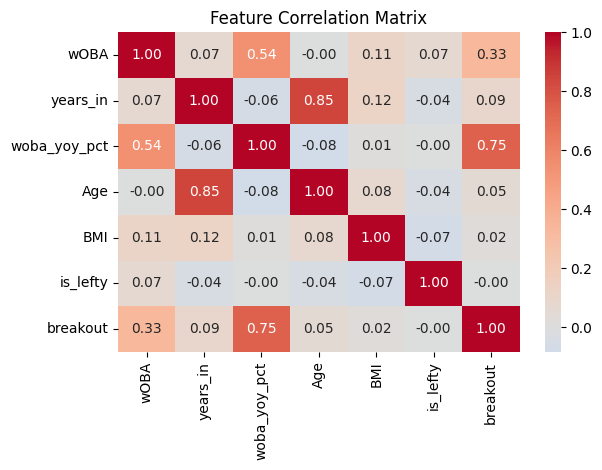

In [205]:
#WILL UPDATE AFTER FEATURE ENGINNERING
players_stats['Age'] = players_stats['yearID'] - players_stats['birthYear']
players_stats['BMI'] = (players_stats['weight'] / (players_stats['height']**2)) * 703
players_stats['is_lefty'] = (players_stats['bats'] == 'L').astype(int)

corr_cols = ['wOBA', 'years_in', 'woba_yoy_pct', 'Age', 'BMI', 'is_lefty', 'breakout']

corr = players_stats[corr_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [206]:
features = ['woba_prev_year', 'years_in', 'Age', 'BMI', 'is_lefty']

players_stats_clean = players_stats.dropna(subset = features + ['woba_yoy_pct', 'breakout'])

X = players_stats_clean[features]
y_regression = players_stats_clean['woba_yoy_pct']
y_classification = players_stats_clean['breakout']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size = 0.20, random_state = 19)
X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size = 0.20, random_state = 19)
#Add , random_state = 42 after test_size = 0.2 if you want fixed results and not different everytime

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv = 5).fit(X_train_scaled, y_train_reg)
print(f"Lasso R^2 Score: {lasso.score(X_test_scaled, y_test_reg):.4f}")

rf = RandomForestClassifier(n_estimators = 100, random_state = 19)
rf.fit(X_train, y_train_cls)
print("\nRandom Forest Report: ")
print(classification_report(y_test_cls, rf.predict(X_test)))

Lasso R^2 Score: 0.2832

Random Forest Report: 
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       809
           1       0.57      0.34      0.42       265

    accuracy                           0.77      1074
   macro avg       0.69      0.63      0.64      1074
weighted avg       0.75      0.77      0.75      1074



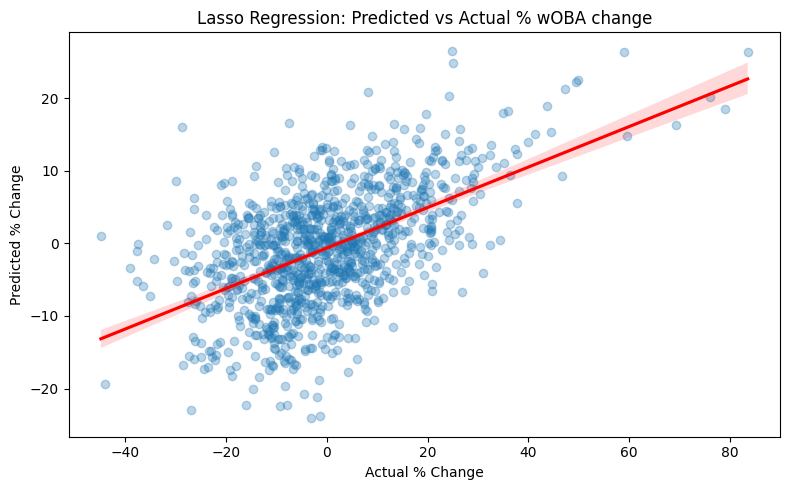

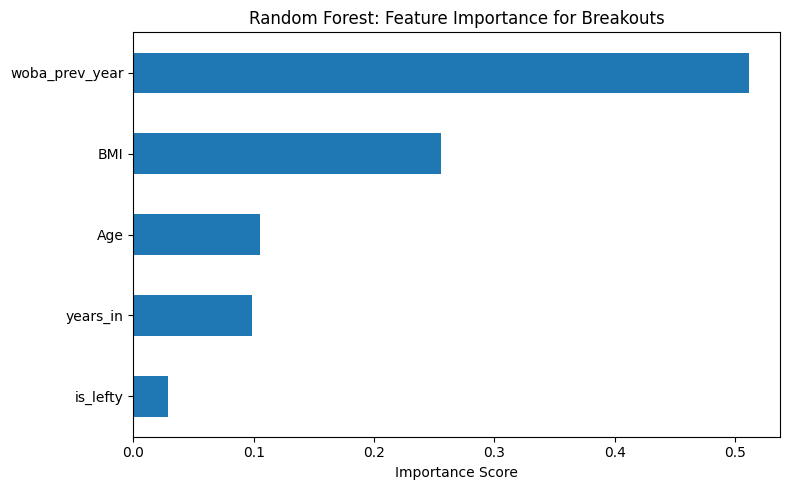

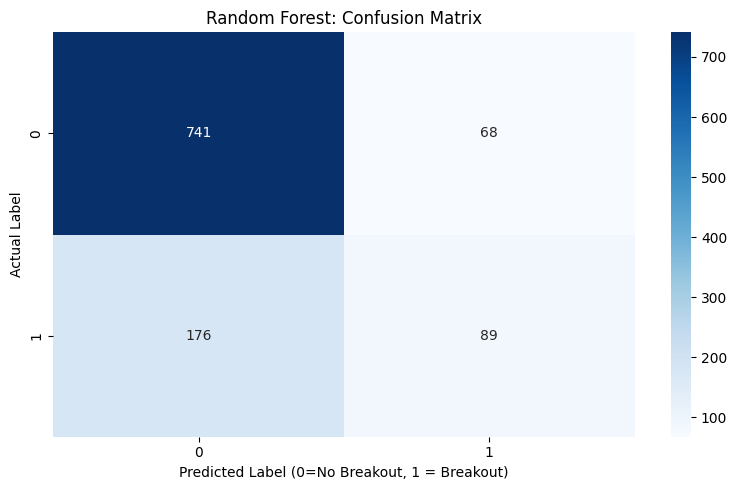

In [207]:
#Lasso Regression: Predictions vs Actual
y_pred_reg = lasso.predict(X_test_scaled)
plt.figure(figsize = (8,5))
sns.regplot(x = y_test_reg, y = y_pred_reg, scatter_kws = {'alpha': 0.3}, line_kws = {'color': 'red'})
plt.title('Lasso Regression: Predicted vs Actual % wOBA change')
plt.xlabel('Actual % Change')
plt.ylabel('Predicted % Change')
plt.tight_layout()
plt.show()

#Random Forest: Importance of Features
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize = (8,5))
importances.plot(kind = 'barh')
plt.title('Random Forest: Feature Importance for Breakouts')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#Confusion Matrix: Accuracy of Classification
cm = confusion_matrix(y_test_cls, rf.predict(X_test))
plt.figure(figsize = (8,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted Label (0=No Breakout, 1 = Breakout)')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [212]:
data_2025 = players_stats[players_stats['yearID'] == 2025].dropna(subset = features).copy()
data_2025['breakout_prob'] = rf.predict_proba(data_2025[features])[:, 1]

top_candidates = data_2025.sort_values('breakout_prob', ascending = False).head(30)
print(top_candidates[['playerID', 'nameFirst', 'nameLast', 'Age', 'woba_prev_year', 'breakout_prob']])

          playerID nameFirst    nameLast   Age  woba_prev_year  breakout_prob
1444470  scottvi01    Victor       Scott  24.0        0.222871           1.00
1578663  taylomi02   Michael      Taylor  34.0        0.244209           0.98
57745     baezja01    Javier        Baez  33.0        0.226764           0.96
377555   davishe01     Henry       Davis  26.0        0.214642           0.96
999422   marteno01    Noelvi       Marte  24.0        0.245037           0.96
742526   hollija01   Jackson    Holliday  22.0        0.253918           0.96
915704     leebr02    Brooks         Lee  24.0        0.254749           0.95
92237     beckjo01    Jordan        Beck  24.0        0.233142           0.95
1540272  storytr01    Trevor       Story  33.0        0.252583           0.93
715795   herrejo04      Jose     Herrera  28.0        0.256809           0.93
943394   loftini01      Nick      Loftin  27.0        0.243771           0.93
1014923  matoslu02      Luis       Matos  23.0        0.252619  